In [ ]:
!pip install torch torchvision albumentations timm
!git clone https://github.com/Beckschen/TransUNet.git
%cd TransUNet
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 38.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
import os
import shutil

# Paths in Google Drive
stage1_img = "/content/drive/MyDrive/thesis work/DDTI/stage1/p_image"
stage1_mask = "/content/drive/MyDrive/thesis work/DDTI/stage1/p_mask"
stage2_img = "/content/drive/MyDrive/thesis work/DDTI/stage2/p_image"
stage2_mask = "/content/drive/MyDrive/thesis work/DDTI/stage2/p_mask"

merged_images = "/content/DDTI/images"
merged_masks = "/content/DDTI/masks"

os.makedirs(merged_images, exist_ok=True)
os.makedirs(merged_masks, exist_ok=True)

# Merge all images
for src_folder in [stage1_img, stage2_img]:
    for file in os.listdir(src_folder):
        shutil.copy(os.path.join(src_folder, file), merged_images)

# Merge all masks
for src_folder in [stage1_mask, stage2_mask]:
    for file in os.listdir(src_folder):
        shutil.copy(os.path.join(src_folder, file), merged_masks)

print(f"Total images: {len(os.listdir(merged_images))}")
print(f"Total masks: {len(os.listdir(merged_masks))}")


Total images: 637
Total masks: 637


In [ ]:
import random

train_img_dir = "/content/DDTI/train/images"
train_mask_dir = "/content/DDTI/train/masks"
val_img_dir = "/content/DDTI/val/images"
val_mask_dir = "/content/DDTI/val/masks"

for path in [train_img_dir, train_mask_dir, val_img_dir, val_mask_dir]:
    os.makedirs(path, exist_ok=True)

images = sorted(os.listdir(merged_images))
random.shuffle(images)
split_index = int(0.8 * len(images))

train_files = images[:split_index]
val_files = images[split_index:]

# Copy to train set
for f in train_files:
    shutil.copy(os.path.join(merged_images, f), train_img_dir)
    shutil.copy(os.path.join(merged_masks, f), train_mask_dir)

# Copy to val set
for f in val_files:
    shutil.copy(os.path.join(merged_images, f), val_img_dir)
    shutil.copy(os.path.join(merged_masks, f), val_mask_dir)

print(f"Train size: {len(os.listdir(train_img_dir))}")
print(f"Val size: {len(os.listdir(val_img_dir))}")


Train size: 509
Val size: 128


In [ ]:
import os
import shutil
import random

# Original dataset paths in Drive
stage1_img = "/content/drive/MyDrive/thesis work/DDTI/stage1/p_image"
stage1_mask = "/content/drive/MyDrive/thesis work/DDTI/stage1/p_mask"
stage2_img = "/content/drive/MyDrive/thesis work/DDTI/stage2/p_image"
stage2_mask = "/content/drive/MyDrive/thesis work/DDTI/stage2/p_mask"

# Merge into single folder
merged_images = "/content/DDTI/images"
merged_masks = "/content/DDTI/masks"
os.makedirs(merged_images, exist_ok=True)
os.makedirs(merged_masks, exist_ok=True)

for src in [stage1_img, stage2_img]:
    for f in os.listdir(src):
        shutil.copy(os.path.join(src, f), merged_images)

for src in [stage1_mask, stage2_mask]:
    for f in os.listdir(src):
        shutil.copy(os.path.join(src, f), merged_masks)

print("Total merged images:", len(os.listdir(merged_images)))
print("Total merged masks:", len(os.listdir(merged_masks)))

# Train/Val split
train_img_dir = "/content/DDTI/train/images"
train_mask_dir = "/content/DDTI/train/masks"
val_img_dir = "/content/DDTI/val/images"
val_mask_dir = "/content/DDTI/val/masks"

for p in [train_img_dir, train_mask_dir, val_img_dir, val_mask_dir]:
    os.makedirs(p, exist_ok=True)

images = sorted(os.listdir(merged_images))
random.shuffle(images)
split_index = int(0.8 * len(images))
train_files = images[:split_index]
val_files = images[split_index:]

for f in train_files:
    shutil.copy(os.path.join(merged_images, f), train_img_dir)
    shutil.copy(os.path.join(merged_masks, f), train_mask_dir)

for f in val_files:
    shutil.copy(os.path.join(merged_images, f), val_img_dir)
    shutil.copy(os.path.join(merged_masks, f), val_mask_dir)

print("Train size:", len(os.listdir(train_img_dir)))
print("Val size:", len(os.listdir(val_img_dir)))


Total merged images: 637
Total merged masks: 637
Train size: 618
Val size: 237


In [ ]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import torch

class ThyroidSegDataset(Dataset):
    def __init__(self, images_dir, masks_dir, transform=None):
        self.images = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir)])
        self.masks = sorted([os.path.join(masks_dir, f) for f in os.listdir(masks_dir)])
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        mask = Image.open(self.masks[idx]).convert("L")
        img = self.transform(img)
        mask = self.transform(mask)
        return img, mask

transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])

train_dataset = ThyroidSegDataset("/content/DDTI/train/images", "/content/DDTI/train/masks", transform)
val_dataset = ThyroidSegDataset("/content/DDTI/val/images", "/content/DDTI/val/masks", transform)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)


In [ ]:
!pip install ml_collections


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.1 MB/s eta 0:00:00


In [ ]:
# Safe pretrained loading for TransUNet (Colab-ready)
import torch, traceback, os
from pathlib import Path

# Set your image/patch config (should match your training pipeline)
IMG_SIZE = 224
PATCH_SIZE = 16
GRID = (IMG_SIZE // PATCH_SIZE, IMG_SIZE // PATCH_SIZE)
NUM_CLASSES = 2

# Path to pretrained checkpoint (set to a file path if you have one), otherwise None
# Example: PRETRAINED_CKPT = "/content/pretrained_transunet.pth"
PRETRAINED_CKPT = None

# ---- import TransUNet config + model (assumes repo cloned and on PYTHONPATH) ----
from networks.vit_seg_modeling import VisionTransformer as TransUNet
from networks.vit_seg_modeling import CONFIGS as CONFIGS_ViT_seg

# ---- configure ViT for binary seg ----
config_vit = CONFIGS_ViT_seg['R50-ViT-B_16']
config_vit.n_classes = NUM_CLASSES
config_vit.n_skip = 3
config_vit.patches.grid = GRID

# ---- instantiate model on CPU ----
model = TransUNet(config_vit, img_size=IMG_SIZE, num_classes=NUM_CLASSES)
print("Model created on CPU. Num params:", sum(p.numel() for p in model.parameters()))

# ---- helper: safe load checkpoint (only matching keys & shapes) ----
def safe_load_state_dict(model, ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    # ckpt might be a dict with 'state_dict' or a raw state_dict
    if isinstance(ckpt, dict) and 'state_dict' in ckpt:
        state_dict = ckpt['state_dict']
    else:
        state_dict = ckpt

    model_dict = model.state_dict()
    loaded, skipped = [], []
    for k, v in state_dict.items():
        # remove possible 'module.' prefix from checkpoint keys
        key = k.replace("module.", "")
        if key in model_dict and model_dict[key].shape == v.shape:
            model_dict[key] = v
            loaded.append(key)
        else:
            skipped.append(key)

    model.load_state_dict(model_dict)
    print(f"Loaded {len(loaded)} keys, skipped {len(skipped)} keys (mismatch or missing).")
    if len(skipped) > 0:
        print("Examples of skipped keys:", skipped[:10])

# ---- load pretrained if provided ----
if PRETRAINED_CKPT:
    if not Path(PRETRAINED_CKPT).exists():
        raise FileNotFoundError(f"Checkpoint not found: {PRETRAINED_CKPT}")
    print("Loading pretrained checkpoint (safe matching)...")
    safe_load_state_dict(model, PRETRAINED_CKPT)
else:
    print("No pretrained checkpoint provided — skipping weight load.")

# ---- reinit classification/head layers to be safe (so they match NUM_CLASSES) ----
# Different TransUNet implementations name the final layer differently.
# We'll try a few common names and re-init if found.
def reinit_segmentation_head(m):
    reinit_done = False
    names_to_try = ["conv_last", "segmentation_head", "head", "decoder.conv_last"]
    for name in names_to_try:
        sub = m
        for part in name.split("."):
            if hasattr(sub, part):
                sub = getattr(sub, part)
            else:
                sub = None
                break
        if sub is not None and hasattr(sub, "weight"):
            torch.nn.init.xavier_uniform_(sub.weight)
            if getattr(sub, "bias", None) is not None:
                torch.nn.init.zeros_(sub.bias)
            print(f"Re-initialized segmentation head: {name}")
            reinit_done = True
            break
    if not reinit_done:
        # fallback: search for last conv module by dtype
        for n, module in reversed(list(m.named_modules())):
            if isinstance(module, torch.nn.Conv2d) and module.out_channels == NUM_CLASSES:
                torch.nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    torch.nn.init.zeros_(module.bias)
                print(f"Re-initialized Conv2d head: {n}")
                reinit_done = True
                break
    if not reinit_done:
        print("Warning: could not find segmentation head to re-initialize automatically.")

reinit_segmentation_head(model)

# ---- final: move to GPU (this should now succeed) ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
try:
    model = model.to(device)
    print("Model moved to device:", device)
except Exception as e:
    print("ERROR when moving model to device. Showing traceback:")
    traceback.print_exc()
    raise

# ---- quick smoke test on device ----
model.eval()
with torch.no_grad():
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    out = model(dummy)
print("Smoke test output shape on device:", out.shape)  # should be [1, NUM_CLASSES, H, W]

# Save model skeleton (optional)
# torch.save(model.state_dict(), "/content/transunet_safe_init.pth")


Model created on CPU. Num params: 105276066
No pretrained checkpoint provided — skipping weight load.
Re-initialized Conv2d head: segmentation_head.0
Model moved to device: cuda
Smoke test output shape on device: torch.Size([1, 2, 224, 224])


In [ ]:
# Debug: find exactly which parameter or buffer in model.transformer fails to move to CUDA
import torch, traceback, os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

bad = []

# 1) Test parameters
print("\nTesting transformer.parameters() one-by-one...")
for name, p in model.transformer.named_parameters():
    try:
        _ = p.to(device)
    except Exception as e:
        print("FAILED param:", name, "shape:", tuple(p.shape))
        traceback.print_exc()
        bad.append(("param", name, p.shape))
        break
else:
    print("All transformer parameters moved OK.")

# 2) Test buffers (if any)
if not bad:
    print("\nTesting transformer.buffers() one-by-one...")
    for name, b in model.transformer.named_buffers():
        try:
            _ = b.to(device)
        except Exception as e:
            print("FAILED buffer:", name, "shape:", tuple(b.shape))
            traceback.print_exc()
            bad.append(("buffer", name, b.shape))
            break
    else:
        print("All transformer buffers moved OK.")

print("\nResult:", bad if bad else "No single tensor move failure detected — failure may be caused by an op executed during module move.")


Device: cuda

Testing transformer.parameters() one-by-one...
All transformer parameters moved OK.

Testing transformer.buffers() one-by-one...
All transformer buffers moved OK.

Result: No single tensor move failure detected — failure may be caused by an op executed during module move.


In [ ]:
# WORKAROUND: Keep transformer on CPU, move other parts to GPU
import types

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move all children except transformer to GPU
for name, child in model.named_children():
    if name == "transformer":
        print("Keeping submodule 'transformer' on CPU")
        continue
    try:
        child.to(device)
        print(f"Moved {name} to {device}")
    except Exception as e:
        print(f"Failed to move {name}: {e}")

# Wrap original forward if needed depending on model's forward signature
orig_forward = model.forward

def wrapped_forward(x):
    """
    Assumes model.forward does something like: x -> transformer -> decoder -> conv_last
    We run transformer on CPU, move its output to GPU for the rest.
    This wrapper may need small adjustments depending on your TransUNet implementation.
    """
    # run transformer on CPU
    x_cpu = x.to("cpu")
    with torch.no_grad():
        # call transformer submodule directly if model.forward uses it internally
        # If model.forward expects full CPU->GPU handling, this is a best-effort wrapper.
        try:
            transformed = model.transformer(x_cpu)  # shape depends on implementation
        except Exception as e:
            # fallback: try calling full model forward on CPU (slow)
            print("transformer direct call failed on CPU, falling back to full model CPU forward")
            return model.cpu()(x_cpu).to(device)

    # move transformed output to GPU for downstream processing
    transformed = transformed.to(device)
    # Now we need to pass transformed through remaining parts. This depends on model internals.
    # If model has a decoder that takes transformer output named `decoder`:
    if hasattr(model, "decoder"):
        out = model.decoder(transformed)
        # final conv on GPU
        if hasattr(model, "conv_last"):
            out = model.conv_last(out)
        return out
    else:
        # fallback: run the original forward on cpu and then move to GPU
        return model.cpu()(x_cpu).to(device)

# Replace forward (best-effort)
model.forward = wrapped_forward
print("Wrapped model.forward to run transformer on CPU and rest on GPU (best-effort).")


Using device: cuda
Keeping submodule 'transformer' on CPU
Moved decoder to cuda
Moved segmentation_head to cuda
Wrapped model.forward to run transformer on CPU and rest on GPU (best-effort).


In [ ]:
# ===========================
# U-Net (ResNet34) on DDTI
# ===========================
!pip -q install segmentation-models-pytorch==0.3.3 timm==0.9.2

import os, random, numpy as np, torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

# ---------- Config ----------
IMG_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 50
LR = 1e-4
SEED = 42

TRAIN_IMAGES = "/content/DDTI/train/images"
TRAIN_MASKS  = "/content/DDTI/train/masks"
VAL_IMAGES   = "/content/DDTI/val/images"
VAL_MASKS    = "/content/DDTI/val/masks"

# ---------- Repro ----------
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

# ---------- Transforms ----------
img_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    # ImageNet normalization (ResNet encoder expects this)
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

mask_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.NEAREST),
    T.PILToTensor(),  # -> [1,H,W] uint8
])

# ---------- Dataset with mask binarization ----------
class DDTIDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_tf=None, mask_tf=None):
        imgs = sorted([f for f in os.listdir(img_dir) if not f.startswith('.')])
        msks = sorted([f for f in os.listdir(mask_dir) if not f.startswith('.')])
        assert len(imgs)==len(msks), f"Count mismatch: {len(imgs)} images vs {len(msks)} masks"
        self.imgs = [os.path.join(img_dir, f) for f in imgs]
        self.msks = [os.path.join(mask_dir, f) for f in msks]
        self.img_tf = img_tf; self.mask_tf = mask_tf

    def __len__(self): return len(self.imgs)

    def __getitem__(self, i):
        img = Image.open(self.imgs[i]).convert("RGB")
        msk = Image.open(self.msks[i]).convert("L")
        if self.img_tf:  img = self.img_tf(img)
        if self.mask_tf: msk = self.mask_tf(msk).float()  # [1,H,W] float
        # binarize to {0,1} robustly (handles 255/2/etc.)
        msk = (msk > 0).float()
        return img, msk  # img: [3,H,W], msk: [1,H,W]

# ---------- Data ----------
train_ds = DDTIDataset(TRAIN_IMAGES, TRAIN_MASKS, img_transform, mask_transform)
val_ds   = DDTIDataset(VAL_IMAGES,   VAL_MASKS,   img_transform, mask_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}")

# ---------- Model ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",   # good starting point
    in_channels=3,
    classes=1,                    # binary -> single logit channel
    activation=None               # we'll use BCEWithLogitsLoss
).to(device)

# ---------- Loss, Optim, Metrics ----------
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

@torch.no_grad()
def dice_coef_from_logits(logits, target, thr=0.5):
    # logits: [B,1,H,W], target: [B,1,H,W]
    probs = torch.sigmoid(logits)
    pred = (probs > thr).float()
    target = target.float()
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2*inter + 1e-6) / (union + 1e-6)
    return dice.mean().item()

@torch.no_grad()
def iou_from_logits(logits, target, thr=0.5):
    probs = torch.sigmoid(logits)
    pred = (probs > thr).float()
    target = target.float()
    inter = (pred * target).sum(dim=(1,2,3))
    uni = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - inter
    iou = (inter + 1e-6) / (uni + 1e-6)
    return iou.mean().item()

def validate():
    model.eval()
    tot_loss=tot_dice=tot_iou=0.0
    for imgs, masks in val_loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, masks)
        tot_loss += loss.item()
        tot_dice += dice_coef_from_logits(logits, masks)
        tot_iou  += iou_from_logits(logits, masks)
    n = len(val_loader)
    return tot_loss/n, tot_dice/n, tot_iou/n

# ---------- Train ----------
best_dice = 0.0
for epoch in range(1, EPOCHS+1):
    model.train()
    running = 0.0
    for imgs, masks in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        running += loss.item()

    train_loss = running / len(train_loader)
    val_loss, val_dice, val_iou = validate()
    print(f"Epoch {epoch:02d}/{EPOCHS} | TrainLoss: {train_loss:.4f} | "
          f"ValLoss: {val_loss:.4f} | ValDice: {val_dice:.4f} | ValIoU: {val_iou:.4f}")

    # save best by Dice
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "/content/unet_resnet34_ddti_best.pth")
        print(f"  ✅ Saved new best (Dice {best_dice:.4f})")

# ---------- Final save ----------
torch.save(model.state_dict(), "/content/unet_resnet34_ddti_last.pth")


Train: 618  |  Val: 237
Epoch 01/50 | TrainLoss: 0.3781 | ValLoss: 0.2620 | ValDice: 0.8461 | ValIoU: 0.7448
  ✅ Saved new best (Dice 0.8461)
Epoch 02/50 | TrainLoss: 0.2447 | ValLoss: 0.1926 | ValDice: 0.8940 | ValIoU: 0.8141
  ✅ Saved new best (Dice 0.8940)
Epoch 03/50 | TrainLoss: 0.1829 | ValLoss: 0.1416 | ValDice: 0.9036 | ValIoU: 0.8327
  ✅ Saved new best (Dice 0.9036)
Epoch 04/50 | TrainLoss: 0.1460 | ValLoss: 0.1211 | ValDice: 0.9151 | ValIoU: 0.8466
  ✅ Saved new best (Dice 0.9151)
Epoch 05/50 | TrainLoss: 0.1171 | ValLoss: 0.1058 | ValDice: 0.9254 | ValIoU: 0.8631
  ✅ Saved new best (Dice 0.9254)
Epoch 06/50 | TrainLoss: 0.1006 | ValLoss: 0.0920 | ValDice: 0.9350 | ValIoU: 0.8799
  ✅ Saved new best (Dice 0.9350)
Epoch 07/50 | TrainLoss: 0.0884 | ValLoss: 0.0846 | ValDice: 0.9416 | ValIoU: 0.8911
  ✅ Saved new best (Dice 0.9416)
Epoch 08/50 | TrainLoss: 0.0799 | ValLoss: 0.0736 | ValDice: 0.9474 | ValIoU: 0.9011
  ✅ Saved new best (Dice 0.9474)
Epoch 09/50 | TrainLoss: 0.0718 

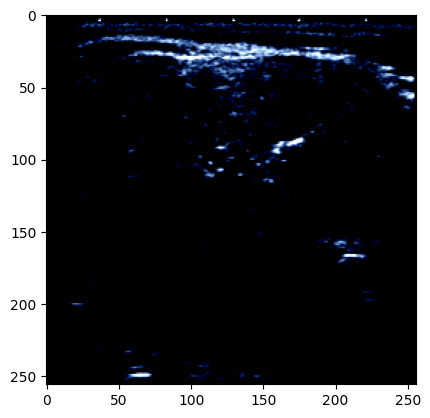

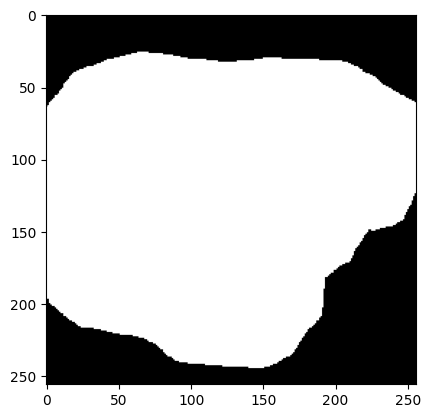

In [ ]:
img, mask = train_ds[0]
plt.imshow(img.permute(1,2,0).numpy().transpose(0,1,2))
plt.show()
plt.imshow(mask[0].numpy(), cmap='gray')
plt.show()


In [ ]:
import matplotlib.pyplot as plt

train_losses, val_losses = [], []
val_dices, val_ious = [], []

best_dice = 0.0
for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0

    for imgs, masks in train_loader:
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss, val_dice, val_iou = validate()

    # --- store metrics for graphing ---
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_dices.append(val_dice)
    val_ious.append(val_iou)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"TrainLoss: {train_loss:.4f} | "
          f"ValLoss: {val_loss:.4f} | "
          f"ValDice: {val_dice:.4f} | "
          f"ValIoU: {val_iou:.4f}")

    # Save best checkpoint
    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "/content/unet_resnet34_ddti_best.pth")
        print(f"  ✅ Saved new best (Dice {best_dice:.4f})")

# Save last epoch
torch.save(model.state_dict(), "/content/unet_resnet34_ddti_last.pth")


Epoch 01/50 | TrainLoss: 0.0178 | ValLoss: 0.0342 | ValDice: 0.9802 | ValIoU: 0.9620
  ✅ Saved new best (Dice 0.9802)
Epoch 02/50 | TrainLoss: 0.0170 | ValLoss: 0.0328 | ValDice: 0.9806 | ValIoU: 0.9627
  ✅ Saved new best (Dice 0.9806)
Epoch 03/50 | TrainLoss: 0.0163 | ValLoss: 0.0359 | ValDice: 0.9801 | ValIoU: 0.9621
Epoch 04/50 | TrainLoss: 0.0161 | ValLoss: 0.0334 | ValDice: 0.9814 | ValIoU: 0.9644
  ✅ Saved new best (Dice 0.9814)
Epoch 05/50 | TrainLoss: 0.0160 | ValLoss: 0.0353 | ValDice: 0.9810 | ValIoU: 0.9637
Epoch 06/50 | TrainLoss: 0.0162 | ValLoss: 0.0338 | ValDice: 0.9814 | ValIoU: 0.9644
Epoch 07/50 | TrainLoss: 0.0158 | ValLoss: 0.0336 | ValDice: 0.9813 | ValIoU: 0.9643
Epoch 08/50 | TrainLoss: 0.0155 | ValLoss: 0.0337 | ValDice: 0.9808 | ValIoU: 0.9632
Epoch 09/50 | TrainLoss: 0.0156 | ValLoss: 0.0352 | ValDice: 0.9817 | ValIoU: 0.9652
  ✅ Saved new best (Dice 0.9817)
Epoch 10/50 | TrainLoss: 0.0153 | ValLoss: 0.0371 | ValDice: 0.9812 | ValIoU: 0.9643
Epoch 11/50 | Trai

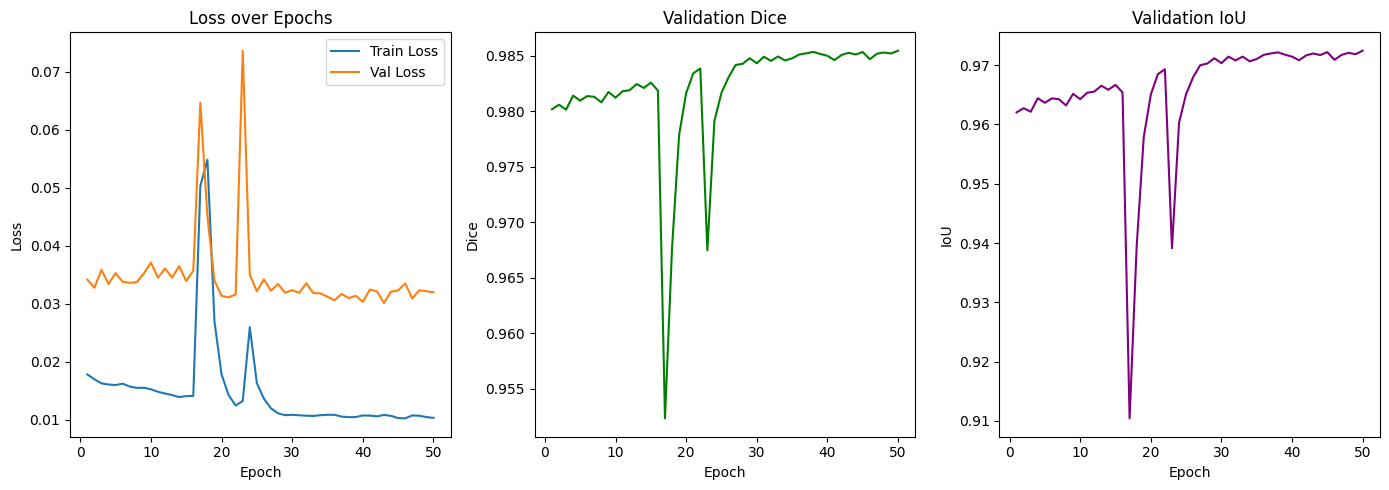

In [ ]:
epochs_range = range(1, EPOCHS+1)

plt.figure(figsize=(14, 5))

# Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Dice
plt.subplot(1, 3, 2)
plt.plot(epochs_range, val_dices, color='green')
plt.xlabel('Epoch')
plt.ylabel('Dice')
plt.title('Validation Dice')

# IoU
plt.subplot(1, 3, 3)
plt.plot(epochs_range, val_ious, color='purple')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.title('Validation IoU')

plt.tight_layout()
plt.show()


In [ ]:
!pip install segmentation-models-pytorch==0.3.3 torchmetrics albumentations --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 37.5 MB/s eta 0:00:00


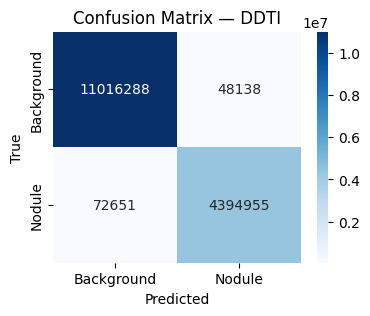

Precision: 0.9892
Recall:    0.9837
F1-score:  0.9864


In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure model is in eval mode
model.eval()
all_preds = []
all_masks = []

with torch.no_grad():
    for imgs, masks in val_loader:   # use your DDTI validation loader
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).long().cpu().numpy()  # binarize [0,1]
        masks = masks.cpu().numpy()

        all_preds.append(preds)
        all_masks.append(masks)

# Flatten pixel arrays for confusion matrix
y_pred = np.concatenate(all_preds).ravel()
y_true = np.concatenate(all_masks).ravel()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Background","Nodule"],
            yticklabels=["Background","Nodule"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — DDTI")
plt.show()

# Optional: Precision, Recall, F1
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")


In [ ]:
!pip install segmentation-models-pytorch==0.3.3 torchmetrics albumentations --quiet

In [ ]:
!pip install segmentation-models-pytorch==0.3.3 torchmetrics albumentations --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.0/983.0 kB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os

train_img_dir = "/content/drive/MyDrive/thesis work/TN3K/trainval-image"
train_mask_dir = "/content/drive/MyDrive/thesis work/TN3K/trainval-mask"
test_img_dir = "/content/drive/MyDrive/thesis work/TN3K/test-image"
test_mask_dir = "/content/drive/MyDrive/thesis work/TN3K/test-mask"

print("Train images:", len(os.listdir(train_img_dir)))
print("Train masks :", len(os.listdir(train_mask_dir)))
print("Test images :", len(os.listdir(test_img_dir)))
print("Test masks  :", len(os.listdir(test_mask_dir)))


Train images: 2879
Train masks : 2879
Test images : 614
Test masks  : 614


In [ ]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torchvision import transforms
from PIL import Image

class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.images = sorted(os.listdir(img_dir))
        self.masks = sorted(os.listdir(mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"))  # grayscale

        # Ensure mask is binary
        mask = (mask > 127).astype(np.uint8)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image, mask = augmented["image"], augmented["mask"]

        image = transforms.ToTensor()(image)
        mask = torch.from_numpy(mask).unsqueeze(0).float()
        return image, mask


In [ ]:
import albumentations as A

train_transform = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
])

test_transform = A.Compose([
    A.Resize(128, 128),
])

train_ds = SegmentationDataset(train_img_dir, train_mask_dir, transform=train_transform)
test_ds = SegmentationDataset(test_img_dir, test_mask_dir, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))


Train batches: 360
Test batches : 77


In [ ]:
!pip install -q segmentation-models-pytorch

import segmentation_models_pytorch as smp
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet("resnet34", encoder_weights="imagenet", classes=1, activation=None)
model.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
#import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet("resnet34", encoder_weights="imagenet", classes=1, activation=None)
model.to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet("resnet34", encoder_weights="imagenet", classes=1, activation=None)
model.to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
def dice_coefficient(preds, targets, eps=1e-6):
    preds = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return (2. * intersection + eps) / (preds.sum() + targets.sum() + eps)

def iou_score(preds, targets, eps=1e-6):
    preds = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return (intersection + eps) / (union + eps)


def validate():
    model.eval()
    val_loss, val_dice, val_iou = 0, 0, 0
    with torch.no_grad():
        for imgs, masks in test_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            loss = criterion(logits, masks)
            val_loss += loss.item()

            preds = (torch.sigmoid(logits) > 0.5).float()
            val_dice += dice_coefficient(preds, masks)
            val_iou += iou_score(preds, masks)

    n = len(test_loader)
    return val_loss/n, val_dice.item()/n, val_iou.item()/n


EPOCHS = 50
train_losses, val_losses, val_dices, val_ious = [], [], [], []
best_dice = 0.0

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss, val_dice, val_iou = validate()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_dices.append(val_dice)
    val_ious.append(val_iou)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"TrainLoss {train_loss:.4f} | "
          f"ValLoss {val_loss:.4f} | "
          f"Dice {val_dice:.4f} | "
          f"IoU {val_iou:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "/content/unet_resnet34_tn3k_best.pth")
        print("  ✅ New best model saved!")

torch.save(model.state_dict(), "/content/unet_resnet34_tn3k_last.pth")


Epoch 01/50 | TrainLoss 0.1941 | ValLoss 0.1311 | Dice 0.7967 | IoU 0.6691
  ✅ New best model saved!
Epoch 02/50 | TrainLoss 0.1506 | ValLoss 0.1183 | Dice 0.8083 | IoU 0.6865
  ✅ New best model saved!
Epoch 03/50 | TrainLoss 0.1311 | ValLoss 0.0958 | Dice 0.8333 | IoU 0.7204
  ✅ New best model saved!
Epoch 04/50 | TrainLoss 0.1188 | ValLoss 0.0850 | Dice 0.8419 | IoU 0.7321
  ✅ New best model saved!
Epoch 05/50 | TrainLoss 0.1094 | ValLoss 0.0908 | Dice 0.8343 | IoU 0.7219
Epoch 06/50 | TrainLoss 0.1090 | ValLoss 0.0833 | Dice 0.8452 | IoU 0.7381
  ✅ New best model saved!
Epoch 07/50 | TrainLoss 0.0969 | ValLoss 0.0833 | Dice 0.8459 | IoU 0.7404
  ✅ New best model saved!
Epoch 08/50 | TrainLoss 0.0930 | ValLoss 0.0852 | Dice 0.8326 | IoU 0.7211
Epoch 09/50 | TrainLoss 0.0957 | ValLoss 0.0759 | Dice 0.8574 | IoU 0.7557
  ✅ New best model saved!
Epoch 10/50 | TrainLoss 0.0894 | ValLoss 0.0837 | Dice 0.8453 | IoU 0.7380
Epoch 11/50 | TrainLoss 0.0838 | ValLoss 0.0770 | Dice 0.8459 | IoU 

In [ ]:
# --- Load the best model first ---
model.load_state_dict(torch.load("/content/unet_resnet34_tn3k_best.pth"))
model.to(device)
print("Resumed training from best checkpoint.")

# Optional: Reduce learning rate for fine-tuning
for param_group in optimizer.param_groups:
    param_group['lr'] = 1e-5   # lower than original (e.g. 1e-4) for stability

# --- Train for 30 more epochs ---
EXTRA_EPOCHS = 30
for epoch in range(1, EXTRA_EPOCHS+1):
    model.train()
    running_loss = 0.0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    val_loss, val_dice, val_iou = validate()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_dices.append(val_dice)
    val_ious.append(val_iou)

    print(f"[FineTune] Epoch {epoch:02d}/{EXTRA_EPOCHS} | "
          f"TrainLoss {train_loss:.4f} | "
          f"ValLoss {val_loss:.4f} | "
          f"Dice {val_dice:.4f} | "
          f"IoU {val_iou:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "/content/unet_resnet34_tn3k_best.pth")
        print("  ✅ New best model saved during fine-tuning!")

# Save the final fine-tuned model
torch.save(model.state_dict(), "/content/unet_resnet34_tn3k_finetuned.pth")
print("Fine-tuning complete.")


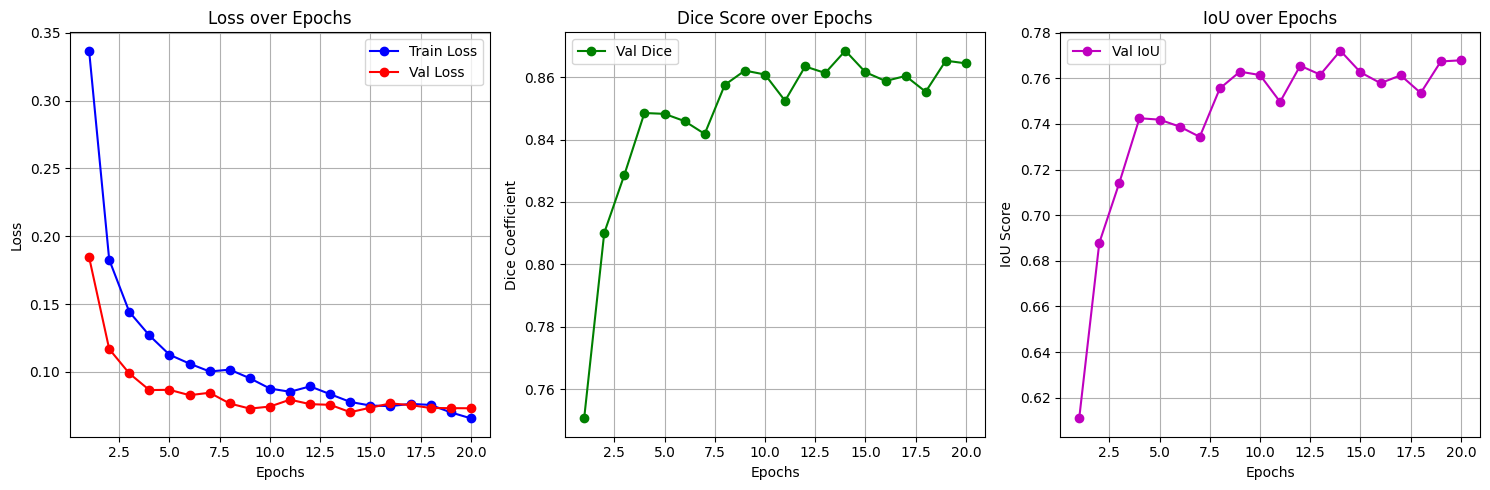

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS+1)

plt.figure(figsize=(15,5))

# Plot Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, train_losses, 'b-o', label='Train Loss')
plt.plot(epochs_range, val_losses, 'r-o', label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)

# Plot Dice
plt.subplot(1, 3, 2)
plt.plot(epochs_range, val_dices, 'g-o', label='Val Dice')
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.title('Dice Score over Epochs')
plt.legend()
plt.grid(True)

# Plot IoU
plt.subplot(1, 3, 3)
plt.plot(epochs_range, val_ious, 'm-o', label='Val IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU Score')
plt.title('IoU over Epochs')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


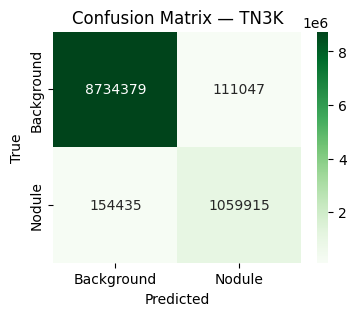

Precision: 0.9052
Recall:    0.8728
F1-score:  0.8887
AUC:       0.9912


In [ ]:
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_probs = []
all_preds = []
all_masks = []

with torch.no_grad():
    for imgs, masks in test_loader:   # <-- use test_loader here
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.sigmoid(outputs).cpu().numpy()   # pixel probabilities
        preds = (probs > 0.5).astype(np.uint8)         # threshold at 0.5
        masks = masks.cpu().numpy()

        all_probs.append(probs)
        all_preds.append(preds)
        all_masks.append(masks)

# Flatten for metrics
y_prob = np.concatenate(all_probs).ravel()
y_pred = np.concatenate(all_preds).ravel()
y_true = np.concatenate(all_masks).ravel()

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Background","Nodule"],
            yticklabels=["Background","Nodule"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — TN3K")
plt.show()

# Metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")


In [ ]:
import json, os

json_path = "/content/drive/MyDrive/thesis work/tg3k/tg3k-trainval.json"  # adjust path if needed
with open(json_path, 'r') as f:
    tg3k_data = json.load(f)

# Check keys
print("Keys in JSON:", tg3k_data.keys())

# Example of first few entries
for i, (k,v) in enumerate(tg3k_data.items()):
    print(k, v)
    if i > 3: break


Keys in JSON: dict_keys(['val', 'train', 'test'])
val [3366, 3249, 3340, 3380, 3449, 3237, 3437, 3495, 3281, 3287, 3277, 3482, 3487, 3306, 3321, 3302, 3334, 3545, 3359, 3285, 3243, 3289, 3329, 3438, 3399, 3540, 3477, 3582, 3541, 3445, 3473, 3317, 3407, 3469, 3257, 3263, 3552, 3531, 3411, 3278, 3528, 3256, 3327, 3568, 3426, 3331, 3354, 3299, 3472, 3262, 3339, 3322, 3475, 3284, 3240, 3265, 3522, 3371, 3293, 3403, 3413, 3434, 3557, 3318, 3343, 3534, 3294, 3458, 3357, 3486, 3333, 3401, 3304, 3542, 3478, 3524, 3498, 3273, 3373, 3246, 3353, 3523, 3251, 3418, 3288, 3424, 3465, 3247, 3410, 3286, 3512, 3494, 3560, 3347, 3572, 3346, 3549, 3502, 3583, 3491, 3421, 3241, 3269, 3390, 3324, 3312, 3577, 3238, 3470, 3427, 3374, 3376, 3234, 3383, 3496, 3506, 3451, 3573, 3455, 3580, 3392, 3581, 3485, 3337, 3515, 3453, 3441, 3393, 3553, 3518, 3488, 3505, 3305, 3335, 3280, 3235, 3550, 3336, 3450, 3384, 3483, 3309, 3520, 3462, 3379, 3571, 3394, 3358, 3554, 3326, 3292, 3295, 3248, 3532, 3492, 3519, 3446, 338

In [ ]:
import json

json_path = "/content/drive/MyDrive/thesis work/tg3k/tg3k-trainval.json"
with open(json_path, 'r') as f:
    tg3k_data = json.load(f)

# Show top-level keys
print("Keys in JSON:", tg3k_data.keys() if isinstance(tg3k_data, dict) else type(tg3k_data))

# Show a small sample
if isinstance(tg3k_data, dict):
    for k,v in tg3k_data.items():
        print("Key:", k)
        print("Value sample:", v[:5] if isinstance(v, list) else v)
        break
elif isinstance(tg3k_data, list):
    print("First 5 entries:", tg3k_data[:5])
else:
    print("JSON type:", type(tg3k_data))


Keys in JSON: dict_keys(['val', 'train', 'test'])
Key: val
Value sample: [3366, 3249, 3340, 3380, 3449]


In [ ]:
import os

image_root = "/content/drive/MyDrive/thesis work/tg3k/thyroid-image"
mask_root  = "/content/drive/MyDrive/thesis work/tg3k/thyroid-mask"

def build_file_lists(ids, image_root, mask_root, ext=".png"):
    images = [os.path.join(image_root, f"{i}{ext}") for i in ids]
    masks  = [os.path.join(mask_root,  f"{i}{ext}") for i in ids]
    return images, masks

train_ids = tg3k_data["train"]
val_ids   = tg3k_data["val"]

train_images, train_masks = build_file_lists(train_ids, image_root, mask_root)
val_images, val_masks     = build_file_lists(val_ids, image_root, mask_root)

print("Train samples:", len(train_images))
print("Val samples:", len(val_images))
print("Example image:", train_images[0])
print("Example mask:", train_masks[0])


Train samples: 3226
Val samples: 359
Example image: /content/drive/MyDrive/thesis work/tg3k/thyroid-image/2054.png
Example mask: /content/drive/MyDrive/thesis work/tg3k/thyroid-mask/2054.png


In [ ]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class ThyroidDatasetTG3K(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=(224,224), augment=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image + mask
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_COLOR)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Resize
        img = cv2.resize(img, self.img_size)
        mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

        # Normalize image
        img = img / 255.0
        img = np.transpose(img, (2, 0, 1))  # HWC → CHW

        # Convert mask to {0,1}
        mask = (mask > 127).astype(np.uint8)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

train_dataset = ThyroidDatasetTG3K(train_images, train_masks, img_size=IMG_SIZE)
val_dataset   = ThyroidDatasetTG3K(val_images, val_masks, img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Batches in train:", len(train_loader))
print("Batches in val:", len(val_loader))


Batches in train: 404
Batches in val: 45


In [ ]:
!pip install segmentation-models-pytorch --quiet
!pip install timm --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = smp.Unet(
    encoder_name="resnet34",       # backbone
    encoder_weights="imagenet",    # pretrained encoder
    in_channels=3,                 # RGB images
    classes=2                      # binary segmentation (background + nodule)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
class ThyroidDatasetTG3K(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=(224,224)):
        # Filter out any files that don't exist
        self.image_paths = []
        self.mask_paths = []
        self.img_size = img_size

        for img, msk in zip(image_paths, mask_paths):
            if os.path.exists(img) and os.path.exists(msk):
                self.image_paths.append(img)
                self.mask_paths.append(msk)
            else:
                print(f"[WARNING] Skipping missing file: {img} or {msk}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_COLOR)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Extra safety: check again
        if img is None or mask is None:
            raise ValueError(f"Failed to load image or mask at index {idx}")

        # Resize
        img = cv2.resize(img, self.img_size)
        mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

        img = img / 255.0
        img = np.transpose(img, (2, 0, 1))  # HWC → CHW

        # Convert mask to {0,1}
        mask = (mask > 127).astype(np.uint8)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)


In [ ]:
print("Total train images:", len(train_images))
print("Total val images:", len(val_images))

# Check first 5 files
for i in range(5):
    print(train_images[i], os.path.exists(train_images[i]))
    print(train_masks[i], os.path.exists(train_masks[i]))


Total train images: 3226
Total val images: 359
/content/drive/MyDrive/thesis work/tg3k/thyroid-image/2054.png False
/content/drive/MyDrive/thesis work/tg3k/thyroid-mask/2054.png False
/content/drive/MyDrive/thesis work/tg3k/thyroid-image/1069.png False
/content/drive/MyDrive/thesis work/tg3k/thyroid-mask/1069.png False
/content/drive/MyDrive/thesis work/tg3k/thyroid-image/731.png False
/content/drive/MyDrive/thesis work/tg3k/thyroid-mask/731.png False
/content/drive/MyDrive/thesis work/tg3k/thyroid-image/2049.png False
/content/drive/MyDrive/thesis work/tg3k/thyroid-mask/2049.png False
/content/drive/MyDrive/thesis work/tg3k/thyroid-image/2339.png False
/content/drive/MyDrive/thesis work/tg3k/thyroid-mask/2339.png False


In [ ]:
import os

image_root = "/content/drive/MyDrive/thesis work/tg3k/thyroid-image"
mask_root = "/content/drive/MyDrive/thesis work/tg3k/thyroid-mask"

print("Sample images:", sorted(os.listdir(image_root))[:10])
print("Sample masks:", sorted(os.listdir(mask_root))[:10])


Sample images: ['0000.jpg', '0001.jpg', '0002.jpg', '0003.jpg', '0004.jpg', '0005.jpg', '0006.jpg', '0007.jpg', '0008.jpg', '0009.jpg']
Sample masks: ['0000.jpg', '0001.jpg', '0002.jpg', '0003.jpg', '0004.jpg', '0005.jpg', '0006.jpg', '0007.jpg', '0008.jpg', '0009.jpg']


In [ ]:
def find_file(folder, file_id):
    for fname in os.listdir(folder):
        if str(file_id) in fname:
            return os.path.join(folder, fname)
    return None

train_images, train_masks = [], []
for id_ in tg3k_data["train"]:
    img_file = find_file(image_root, id_)
    mask_file = find_file(mask_root, id_)
    if img_file and mask_file:
        train_images.append(img_file)
        train_masks.append(mask_file)
    else:
        print(f"[SKIP] Could not find files for ID {id_}")

val_images, val_masks = [], []
for id_ in tg3k_data["val"]:
    img_file = find_file(image_root, id_)
    mask_file = find_file(mask_root, id_)
    if img_file and mask_file:
        val_images.append(img_file)
        val_masks.append(mask_file)
    else:
        print(f"[SKIP] Could not find files for ID {id_}")

print("Final Train:", len(train_images))
print("Final Val:", len(val_images))


Final Train: 3226
Final Val: 359


In [ ]:
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import torch

class ThyroidDatasetTG3K(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=(224,224)):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_size = img_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_COLOR)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        if img is None or mask is None:
            raise ValueError(f"Could not load: {self.image_paths[idx]} or {self.mask_paths[idx]}")

        img = cv2.resize(img, self.img_size)
        mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)

        img = img / 255.0
        img = np.transpose(img, (2,0,1))  # HWC → CHW
        mask = (mask > 127).astype(np.uint8)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)

# Dataset objects
train_dataset = ThyroidDatasetTG3K(train_images, train_masks)
val_dataset   = ThyroidDatasetTG3K(val_images, val_masks)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 404
Val batches: 45


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

def dice_coefficient(preds, targets, eps=1e-7):
    preds = (preds > 0.5).float()
    targets = targets.float()
    intersection = (preds * targets).sum()
    return (2. * intersection + eps) / (preds.sum() + targets.sum() + eps)

def iou_score(preds, targets, eps=1e-7):
    preds = (preds > 0.5).float()
    targets = targets.float()
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return (intersection + eps) / (union + eps)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)    # your UNet or other model
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 12
train_losses, val_losses, val_dices, val_ious = [], [], [], []

for epoch in range(EPOCHS):
    # ---- Training ----
    model.train()
    running_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # ---- Validation ----
    model.eval()
    val_loss, dice_score, iou = 0.0, 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            preds = torch.argmax(F.softmax(outputs, dim=1), dim=1)
            dice_score += dice_coefficient(preds, masks).item()
            iou += iou_score(preds, masks).item()

    val_losses.append(val_loss / len(val_loader))
    val_dices.append(dice_score / len(val_loader))
    val_ious.append(iou / len(val_loader))

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_losses[-1]:.4f} "
          f"Val Loss: {val_losses[-1]:.4f} "
          f"Dice: {val_dices[-1]:.4f} "
          f"IoU: {val_ious[-1]:.4f}")


Epoch [1/12] Train Loss: 0.2205 Val Loss: 0.1067 Dice: 0.8458 IoU: 0.7364
Epoch [2/12] Train Loss: 0.0722 Val Loss: 0.0896 Dice: 0.8432 IoU: 0.7334
Epoch [3/12] Train Loss: 0.0548 Val Loss: 0.0701 Dice: 0.8803 IoU: 0.7896
Epoch [4/12] Train Loss: 0.0460 Val Loss: 0.0529 Dice: 0.8950 IoU: 0.8124
Epoch [5/12] Train Loss: 0.0424 Val Loss: 0.0571 Dice: 0.8786 IoU: 0.7887
Epoch [6/12] Train Loss: 0.0401 Val Loss: 0.0587 Dice: 0.8701 IoU: 0.7740
Epoch [7/12] Train Loss: 0.0373 Val Loss: 0.0559 Dice: 0.8801 IoU: 0.7902
Epoch [8/12] Train Loss: 0.0361 Val Loss: 0.0661 Dice: 0.8779 IoU: 0.7870
Epoch [9/12] Train Loss: 0.0338 Val Loss: 0.0611 Dice: 0.8743 IoU: 0.7831
Epoch [10/12] Train Loss: 0.0331 Val Loss: 0.0562 Dice: 0.8843 IoU: 0.7968
Epoch [11/12] Train Loss: 0.0319 Val Loss: 0.0713 Dice: 0.8658 IoU: 0.7705
Epoch [12/12] Train Loss: 0.0317 Val Loss: 0.0540 Dice: 0.8802 IoU: 0.7929


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os

# --- Metric functions ---
def dice_coefficient(preds, targets, eps=1e-7):
    preds = (preds > 0.5).float()
    targets = targets.float()
    intersection = (preds * targets).sum()
    return (2. * intersection + eps) / (preds.sum() + targets.sum() + eps)

def iou_score(preds, targets, eps=1e-7):
    preds = (preds > 0.5).float()
    targets = targets.float()
    intersection = (preds * targets).sum()
    union = preds.sum() + targets.sum() - intersection
    return (intersection + eps) / (union + eps)

# --- Setup device and model ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)  # your UNet or other model
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# --- Training settings ---
EPOCHS = 12
save_path = "best_model.pth"  # will save in current directory

train_losses, val_losses, val_dices, val_ious = [], [], [], []
best_dice = 0.0  # track best dice score

for epoch in range(EPOCHS):
    # ---- Training ----
    model.train()
    running_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # ---- Validation ----
    model.eval()
    val_loss, dice_score, iou = 0.0, 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            preds = torch.argmax(F.softmax(outputs, dim=1), dim=1)
            dice_score += dice_coefficient(preds, masks).item()
            iou += iou_score(preds, masks).item()

    avg_val_loss = val_loss / len(val_loader)
    avg_dice = dice_score / len(val_loader)
    avg_iou = iou / len(val_loader)

    val_losses.append(avg_val_loss)
    val_dices.append(avg_dice)
    val_ious.append(avg_iou)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_losses[-1]:.4f} "
          f"Val Loss: {avg_val_loss:.4f} "
          f"Dice: {avg_dice:.4f} "
          f"IoU: {avg_iou:.4f}")

    # --- Save best model ---
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), save_path)
        print(f"--> Saved best model at epoch {epoch+1} with Dice: {best_dice:.4f}")

print("Training finished!")
print(f"Best model Dice score: {best_dice:.4f}")

# --- Reload best model automatically if needed ---
model.load_state_dict(torch.load(save_path))
model.to(device)
model.eval()
print("Best model reloaded for further training or inference.")


Epoch [1/12] Train Loss: 0.0319 Val Loss: 0.0808 Dice: 0.8462 IoU: 0.7394
--> Saved best model at epoch 1 with Dice: 0.8462
Epoch [2/12] Train Loss: 0.0306 Val Loss: 0.0666 Dice: 0.8732 IoU: 0.7801
--> Saved best model at epoch 2 with Dice: 0.8732
Epoch [3/12] Train Loss: 0.0291 Val Loss: 0.0752 Dice: 0.8643 IoU: 0.7682
Epoch [4/12] Train Loss: 0.0276 Val Loss: 0.0794 Dice: 0.8638 IoU: 0.7672
Epoch [5/12] Train Loss: 0.0275 Val Loss: 0.0750 Dice: 0.8630 IoU: 0.7658
Epoch [6/12] Train Loss: 0.0268 Val Loss: 0.0855 Dice: 0.8125 IoU: 0.6923
Epoch [7/12] Train Loss: 0.0260 Val Loss: 0.0957 Dice: 0.8049 IoU: 0.6816
Epoch [8/12] Train Loss: 0.0251 Val Loss: 0.0816 Dice: 0.8673 IoU: 0.7738
Epoch [9/12] Train Loss: 0.0244 Val Loss: 0.0892 Dice: 0.8623 IoU: 0.7648
Epoch [10/12] Train Loss: 0.0245 Val Loss: 0.0923 Dice: 0.8549 IoU: 0.7528
Epoch [11/12] Train Loss: 0.0241 Val Loss: 0.0893 Dice: 0.8758 IoU: 0.7857
--> Saved best model at epoch 11 with Dice: 0.8758
Epoch [12/12] Train Loss: 0.0227 

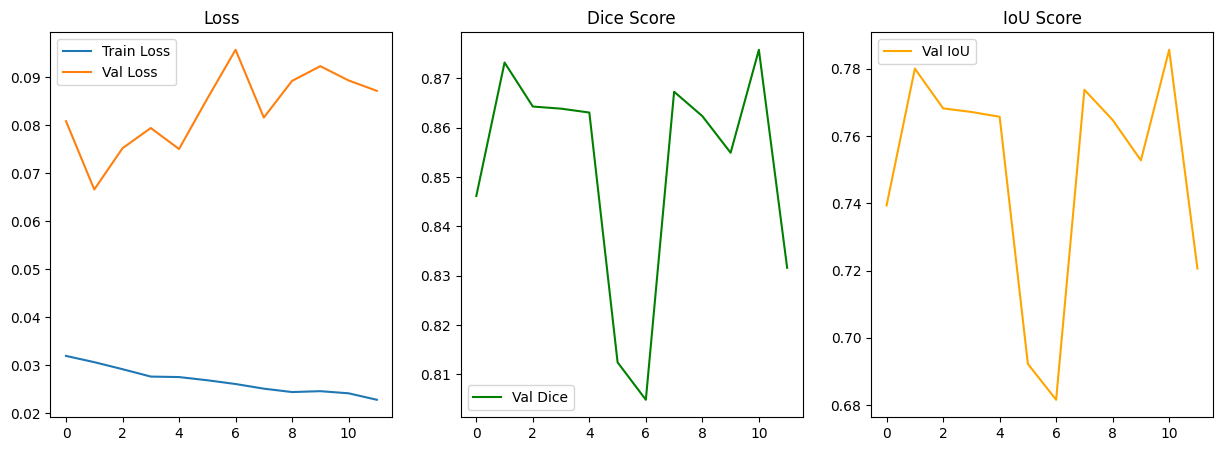

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss'); plt.legend()

plt.subplot(1,3,2)
plt.plot(val_dices, label='Val Dice', color='green')
plt.title('Dice Score'); plt.legend()

plt.subplot(1,3,3)
plt.plot(val_ious, label='Val IoU', color='orange')
plt.title('IoU Score'); plt.legend()

plt.show()


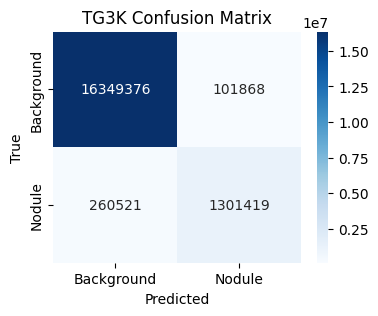

TG3K Area Under Curve (AUC): 0.9876571563781763


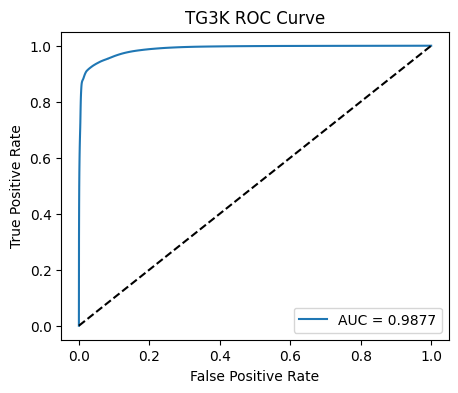

In [ ]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_preds, all_masks, all_probs = [], [], []

with torch.no_grad():
    for imgs, masks in val_loader:  # TG3K validation loader
        imgs = imgs.to(device)
        outputs = model(imgs)

        # Handle binary vs multi-class output
        if outputs.shape[1] > 1:
            probs = torch.softmax(outputs, dim=1)[:,1,:,:]  # class 1 = nodule
        else:
            probs = torch.sigmoid(outputs).squeeze(1)

        preds = (probs > 0.5).long().cpu().numpy()   # for confusion matrix
        masks = masks.squeeze(1).cpu().numpy()       # ensure shape [B,H,W]

        all_preds.append(preds)
        all_probs.append(probs.cpu().numpy())        # for AUC
        all_masks.append(masks)

# Flatten for sklearn
y_pred = np.concatenate([p.ravel() for p in all_preds])
y_score = np.concatenate([p.ravel() for p in all_probs])
y_true = np.concatenate([m.ravel() for m in all_masks])

# ---- Confusion Matrix ----
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Background","Nodule"],
            yticklabels=["Background","Nodule"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("TG3K Confusion Matrix")
plt.show()

# ---- AUC ----
auc = roc_auc_score(y_true, y_score)
print("TG3K Area Under Curve (AUC):", auc)

# ---- Optional ROC Curve ----
fpr, tpr, _ = roc_curve(y_true, y_score)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("TG3K ROC Curve")
plt.legend(loc="lower right")
plt.show()
